Part A - EDA of Titanic

In [ ]:
pip install pandas numpy seaborn matplotlib scikit-learn imbalanced-learn joblib jupyter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.1/915.1 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 30.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

# Better display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [ ]:
df = sns.load_dataset("titanic")

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.to_csv("titanic.csv", index=False)

print("Titanic dataset saved successfully!")

Titanic dataset saved successfully!


In [ ]:
print("Shape:", df.shape)

Shape: (891, 15)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent[missing_percent > 0]

missing_percent.sort_values(ascending=False)

,0
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467


In [ ]:
df.drop(columns=["deck"], inplace=True)

In [ ]:
df["age"].fillna(df["age"].median(), inplace=True)

In [ ]:
df.dropna(subset=["embarked"], inplace=True)

In [ ]:
df.dropna(subset=["embark_town"], inplace=True)

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [ ]:
df.to_csv("titanic.csv", index=False)

print("Cleaned dataset saved.")

Cleaned dataset saved.


Histogram for Age

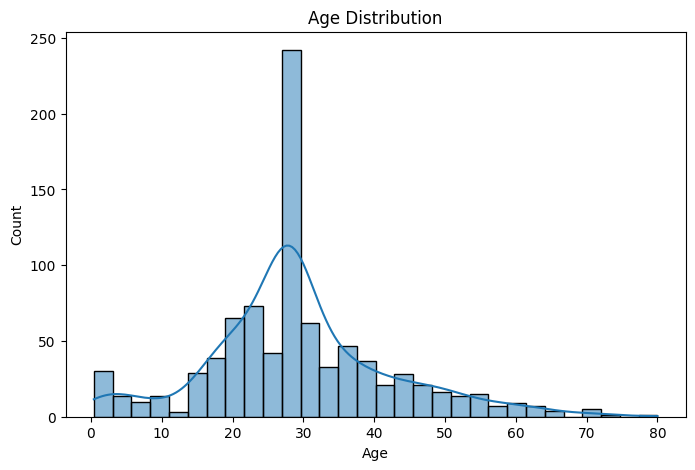

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

Interpretation:

The age distribution shows that most passengers were between 20 and 40 years old. The distribution is slightly right-skewed, with relatively fewer elderly passengers.

Box Plot for Age

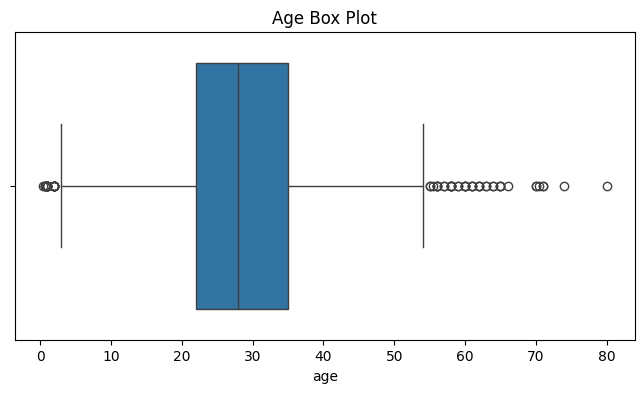

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["age"])

plt.title("Age Box Plot")

plt.show()

Histogram for Fare

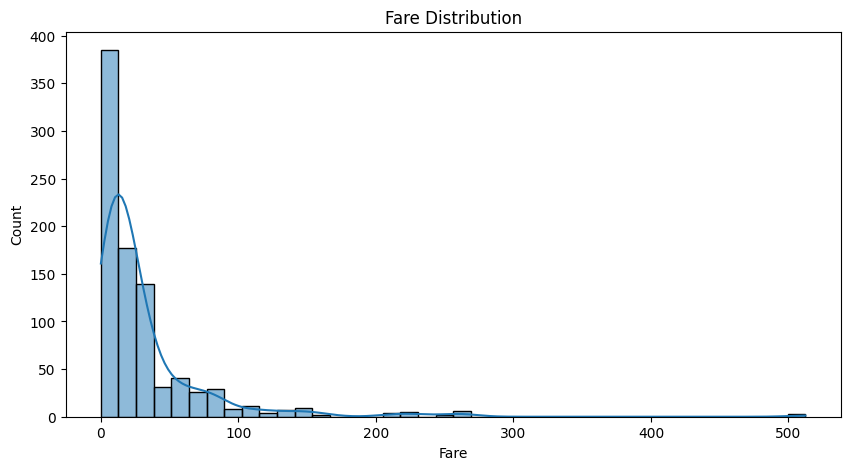

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["fare"], bins=40, kde=True)

plt.title("Fare Distribution")

plt.xlabel("Fare")

plt.ylabel("Count")

plt.show()

Interpretation:

Most passengers paid lower fares, while only a few paid very high fares. This indicates a positively (right) skewed distribution.

Box Plot for Fare

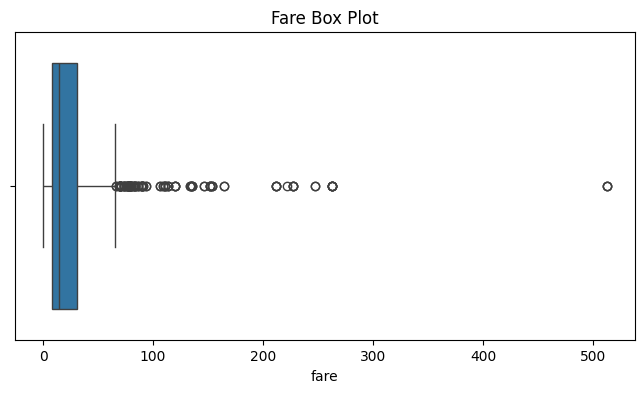

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["fare"])

plt.title("Fare Box Plot")

plt.show()

IQR Outlier Detection

In [ ]:
def iqr_outliers(column):

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"{column.upper()}")

    print("Q1 =", Q1)

    print("Q3 =", Q3)

    print("IQR =", IQR)

    print("Outliers =", len(outliers))

    return outliers

In [ ]:
age_outliers = iqr_outliers("age")

AGE
Q1 = 22.0
Q3 = 35.0
IQR = 13.0
Outliers = 65


In [ ]:
fare_outliers = iqr_outliers("fare")

FARE
Q1 = 7.8958
Q3 = 31.0
IQR = 23.1042
Outliers = 114


Mean, Median and Mode of Fare

In [ ]:
mean_fare = df["fare"].mean()

median_fare = df["fare"].median()

mode_fare = df["fare"].mode()[0]

print("Mean :", mean_fare)

print("Median :", median_fare)

print("Mode :", mode_fare)

Mean : 32.09668087739032
Median : 14.4542
Mode : 8.05


Determine Skewness

In [ ]:
if mean_fare > median_fare > mode_fare:
    print("Fare is Right Skewed")

elif mean_fare < median_fare < mode_fare:
    print("Fare is Left Skewed")

else:
    print("Distribution is nearly Symmetric")

Fare is Right Skewed


Interpretation: Since the Mean > Median > Mode, the Fare distribution is positively (right) skewed. A small number of passengers paid exceptionally high fares, increasing the mean.

In [ ]:
male_survival = df[df["sex"]=="male"]["survived"].mean()*100

female_survival = df[df["sex"]=="female"]["survived"].mean()*100

print(f"Male Survival Rate : {male_survival:.2f}%")

print(f"Female Survival Rate : {female_survival:.2f}%")

Male Survival Rate : 18.89%
Female Survival Rate : 74.04%


Survival Rate by Passenger Class

In [ ]:
for pclass in sorted(df["pclass"].unique()):

    rate = df[df["pclass"]==pclass]["survived"].mean()*100

    print(f"Class {pclass}: {rate:.2f}%")

Class 1: 62.62%
Class 2: 47.28%
Class 3: 24.24%


Survival Rate by Gender and Class

In [ ]:
for gender in ["male","female"]:

    for pclass in [1,2,3]:

        rate = df[
            (df["sex"]==gender) &
            (df["pclass"]==pclass)
        ]["survived"].mean()*100

        print(f"{gender} | Class {pclass} | {rate:.2f}%")

male | Class 1 | 36.89%
male | Class 2 | 15.74%
male | Class 3 | 13.54%
female | Class 1 | 96.74%
female | Class 2 | 92.11%
female | Class 3 | 50.00%


Notice the use of:

In [ ]:
(df["sex"]=="female") & (df["pclass"]==1)

,0
0,False
1,True
2,False
3,True
4,False
...,...
886,False
887,True
888,False
889,False


Correlation

In [ ]:
corr = df[
    [
        "survived",
        "pclass",
        "age",
        "sibsp",
        "parch",
        "fare"
    ]
].corr()

corr

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


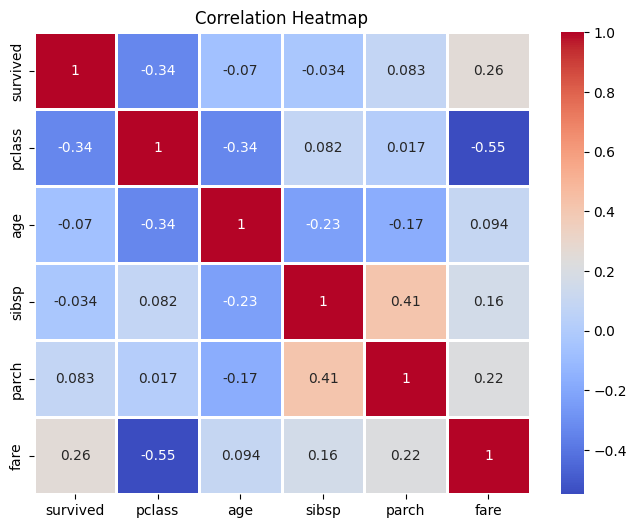

In [ ]:
# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=1
)

plt.title("Correlation Heatmap")

plt.show()

Two Strongest Correlations

In [ ]:
corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .abs()
        .sort_values(ascending=False)
)

top_two = corr_pairs.drop_duplicates().head(2)

print(top_two)

pclass  fare     0.548193
sibsp   parch    0.414542
dtype: float64


Interpretation:

The strongest relationship is between fare and pclass, showing that higher-class passengers generally paid higher fares. Another strong relationship is between sibsp and parch, suggesting that passengers traveling with siblings/spouses often also traveled with parents or children.

Chart-1 Survival by Gender

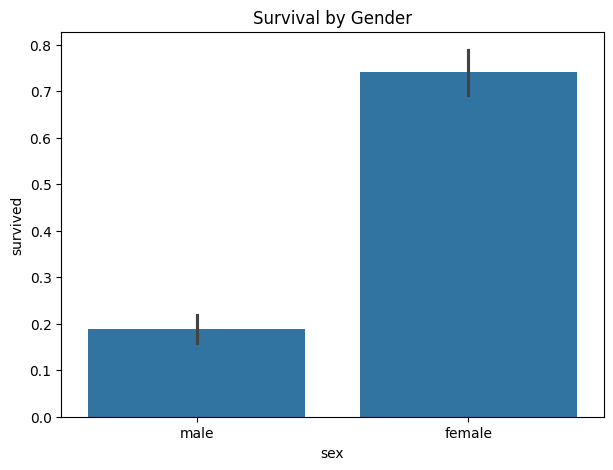

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Survival by Gender")

plt.show()

Interpretation:

Female passengers had a much higher survival rate than male passengers, indicating that rescue efforts prioritized women.

Chart-2 Survival by Passenger Class

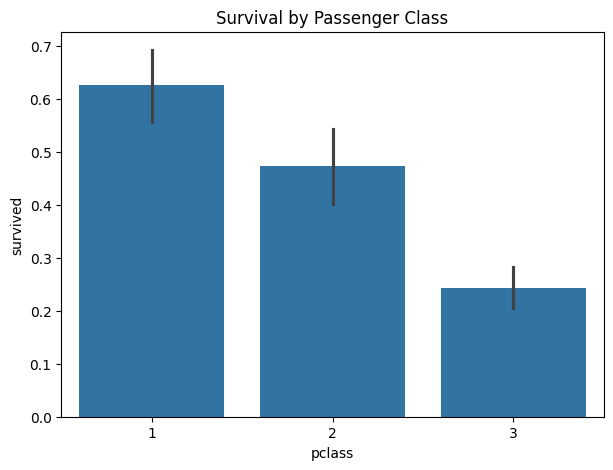

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived"
)

plt.title("Survival by Passenger Class")

plt.show()

Interpretation:

First-class passengers had the highest survival probability, while third-class passengers experienced the lowest.

Chart-3 Age vs Survival

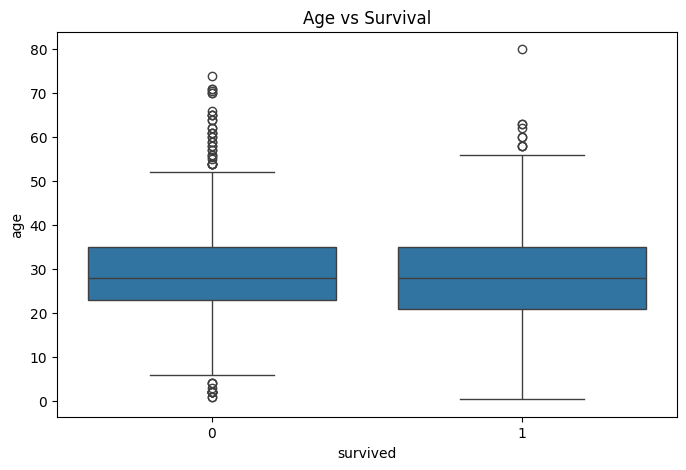

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="survived",
    y="age"
)

plt.title("Age vs Survival")

plt.show()

Interpretation:

Younger passengers generally had a slightly higher survival rate, although the age ranges overlap considerably.

Chart - 4 Age vs Fare

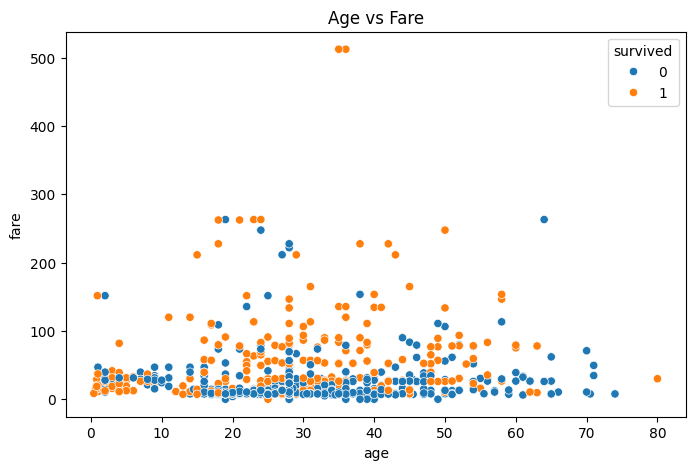

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare")

plt.show()

Interpretation:

Passengers who paid higher fares, especially in higher classes, appear more frequently among survivors.

Standardization Check

In [ ]:
print(df[["age","fare"]].describe())

              age        fare
count  889.000000  889.000000
mean    29.315152   32.096681
std     12.984932   49.697504
min      0.420000    0.000000
25%     22.000000    7.895800
50%     28.000000   14.454200
75%     35.000000   31.000000
max     80.000000  512.329200


Apply StandardScaler

In [ ]:
scaler = StandardScaler()

scaled = scaler.fit_transform(df[["age","fare"]])

scaled_df = pd.DataFrame(
    scaled,
    columns=["age_scaled","fare_scaled"]
)

scaled_df.describe()

,age_scaled,fare_scaled
count,8.890000e+02,8.890000e+02
mean,2.717486e-16,1.398706e-16
std,1.000563e+00,1.000563e+00
min,-2.226536e+00,-6.462044e-01
25%,-5.636741e-01,-4.872378e-01
50%,-1.013399e-01,-3.551972e-01
75%,4.380499e-01,-2.207954e-02
max,3.905556e+00,9.668551e+00


Mean and Standard Deviation

In [ ]:
print("Means")

print(scaled_df.mean())

print()

print("Standard Deviations")

print(scaled_df.std())

Means
age_scaled     2.717486e-16
fare_scaled    1.398706e-16
dtype: float64

Standard Deviations
age_scaled     1.000563
fare_scaled    1.000563
dtype: float64


The means should be approximately 0, and the standard deviations approximately 1, satisfying the assignment's exploratory standardization requirement.

Part B –1 Predictive Modeling

analytics/
    02_modeling.ipynb

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import plot_tree

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from imblearn.over_sampling import SMOTE

from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [ ]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]

y = df["survived"]

Check Class Balance

In [ ]:
print(y.value_counts())

print()

print(y.value_counts(normalize=True)*100)

survived
0    549
1    340
Name: count, dtype: int64

survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64


The dataset is moderately imbalanced.

Therefore we use Stratified Train Test Split so that both training and testing datasets preserve the original class proportions.

Stratified Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [ ]:
print(X_train.shape)

print(X_test.shape)

(711, 7)
(178, 7)


Identify Numeric & Categorical Columns

In [ ]:
numeric_features = [

    "age",
    "fare",
    "sibsp",
    "parch"

]

categorical_features = [

    "sex",
    "embarked",
    "pclass"

]

Numeric Pipeline

In [ ]:
numeric_pipeline = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="median")),

        ("scaler", StandardScaler())

    ]

)

Categorical Pipeline

In [ ]:
categorical_pipeline = Pipeline(

    steps=[

        ("imputer",

         SimpleImputer(strategy="most_frequent")),

        ("encoder",

         OneHotEncoder(handle_unknown="ignore"))

    ]

)

Combine Pipelines

In [ ]:
preprocessor = ColumnTransformer(

    transformers=[

        ("num",

         numeric_pipeline,

         numeric_features),

        ("cat",

         categorical_pipeline,

         categorical_features)

    ]

)

Logistic Regression Pipeline

In [ ]:
logistic_pipeline = Pipeline(

    steps=[

        ("preprocessor",

         preprocessor),

        ("classifier",

         LogisticRegression())

    ]

)

Train Logistic Model

In [ ]:
logistic_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fare', 'sibsp',
                                                   'parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'pclass'])])),
                ('classifier', LogisticRegression())])

Prediction

In [ ]:
logistic_pred = logistic_pipeline.predict(

    X_test

)
logistic_pred

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0])

In [ ]:
logistic_prob = logistic_pipeline.predict_proba(

    X_test

)[:,1]
logistic_prob

array([0.05354664, 0.16728545, 0.16728545, 0.0927711 , 0.07371385,
       0.96048125, 0.10490909, 0.85872649, 0.90339059, 0.08446246,
       0.16728545, 0.80941724, 0.84864009, 0.75921669, 0.91943364,
       0.66663929, 0.7174695 , 0.7734475 , 0.12600382, 0.12981786,
       0.39809153, 0.08225574, 0.13340055, 0.07688545, 0.51264225,
       0.80962155, 0.47640971, 0.76412086, 0.10176987, 0.89659165,
       0.89848231, 0.37478994, 0.09574766, 0.10185254, 0.13075826,
       0.13012933, 0.14611507, 0.09616118, 0.18536339, 0.13766844,
       0.80718268, 0.31701164, 0.95262795, 0.80677679, 0.0930564 ,
       0.04121083, 0.72858189, 0.18210651, 0.57195418, 0.11611661,
       0.07894441, 0.16055834, 0.09566941, 0.71930589, 0.61749778,
       0.25358913, 0.25018039, 0.70680847, 0.13284487, 0.4427671 ,
       0.09893747, 0.53533025, 0.3013907 , 0.07935489, 0.93759987,
       0.20255761, 0.2804173 , 0.45142373, 0.15344078, 0.68539986,
       0.63032822, 0.22211134, 0.58599512, 0.09574766, 0.56152

Evaluation

In [ ]:
cm = confusion_matrix(

    y_test,

    logistic_pred

)

print(cm)

[[98 12]
 [21 47]]


In [ ]:
accuracy = accuracy_score(

    y_test,

    logistic_pred

)
accuracy

0.8146067415730337

In [ ]:
precision = precision_score(

    y_test,

    logistic_pred

)
precision

0.7966101694915254

In [ ]:
recall = recall_score(

    y_test,

    logistic_pred

)
recall

0.6911764705882353

In [ ]:
f1 = f1_score(

    y_test,

    logistic_pred

)
f1

0.7401574803149606

In [ ]:
auc = roc_auc_score(

    y_test,

    logistic_prob

)
auc

np.float64(0.859625668449198)

In [ ]:
print("Accuracy :",accuracy)

print("Precision :",precision)

print("Recall :",recall)

print("F1 :",f1)

print("AUC :",auc)

Accuracy : 0.8146067415730337
Precision : 0.7966101694915254
Recall : 0.6911764705882353
F1 : 0.7401574803149606
AUC : 0.859625668449198


ROC Curve

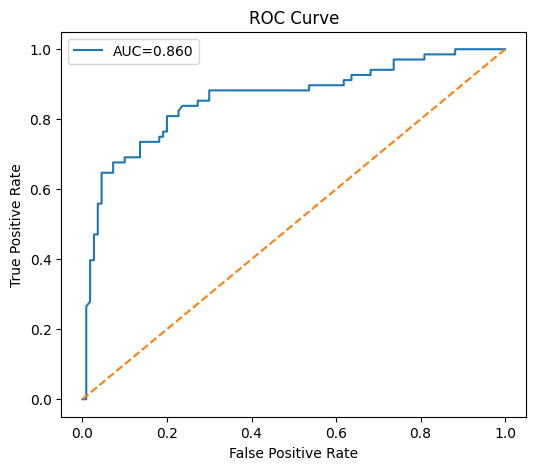

In [ ]:
fpr,tpr,_ = roc_curve(

    y_test,

    logistic_prob

)

plt.figure(figsize=(6,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC={auc:.3f}"

)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

Confusion Matrix Plot

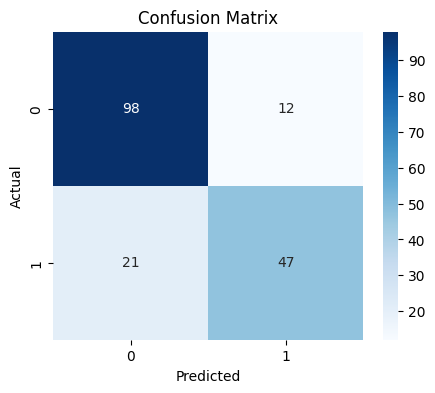

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Part-B-2 Decision Tree Pipeline

In [ ]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [ ]:
decision_tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fare', 'sibsp',
                                                   'parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'pclass'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [ ]:
dt_pred = decision_tree_pipeline.predict(X_test)

dt_prob = decision_tree_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
dt_cm = confusion_matrix(y_test, dt_pred)

dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(y_test, dt_pred)

dt_recall = recall_score(y_test, dt_pred)

dt_f1 = f1_score(y_test, dt_pred)

dt_auc = roc_auc_score(y_test, dt_prob)

In [ ]:
print("Decision Tree Results")
print("----------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC AUC  :", dt_auc)

Decision Tree Results
----------------------
Accuracy : 0.7584269662921348
Precision: 0.6811594202898551
Recall   : 0.6911764705882353
F1 Score : 0.6861313868613139
ROC AUC  : 0.7378342245989304


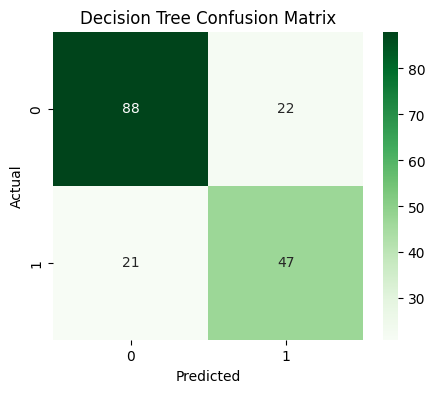

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

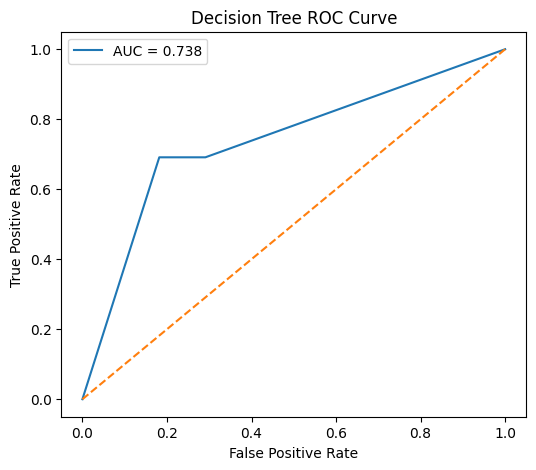

In [ ]:
fpr, tpr, _ = roc_curve(y_test, dt_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {dt_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Decision Tree ROC Curve")

plt.legend()

plt.show()

Visualize the Decision Tree

In [ ]:
preprocessor_fitted = decision_tree_pipeline.named_steps["preprocessor"]

dt_model = decision_tree_pipeline.named_steps["classifier"]

In [ ]:
feature_names = preprocessor_fitted.get_feature_names_out()
feature_names

array(['num__age', 'num__fare', 'num__sibsp', 'num__parch',
       'cat__sex_female', 'cat__sex_male', 'cat__embarked_C',
       'cat__embarked_Q', 'cat__embarked_S', 'cat__pclass_1',
       'cat__pclass_2', 'cat__pclass_3'], dtype=object)

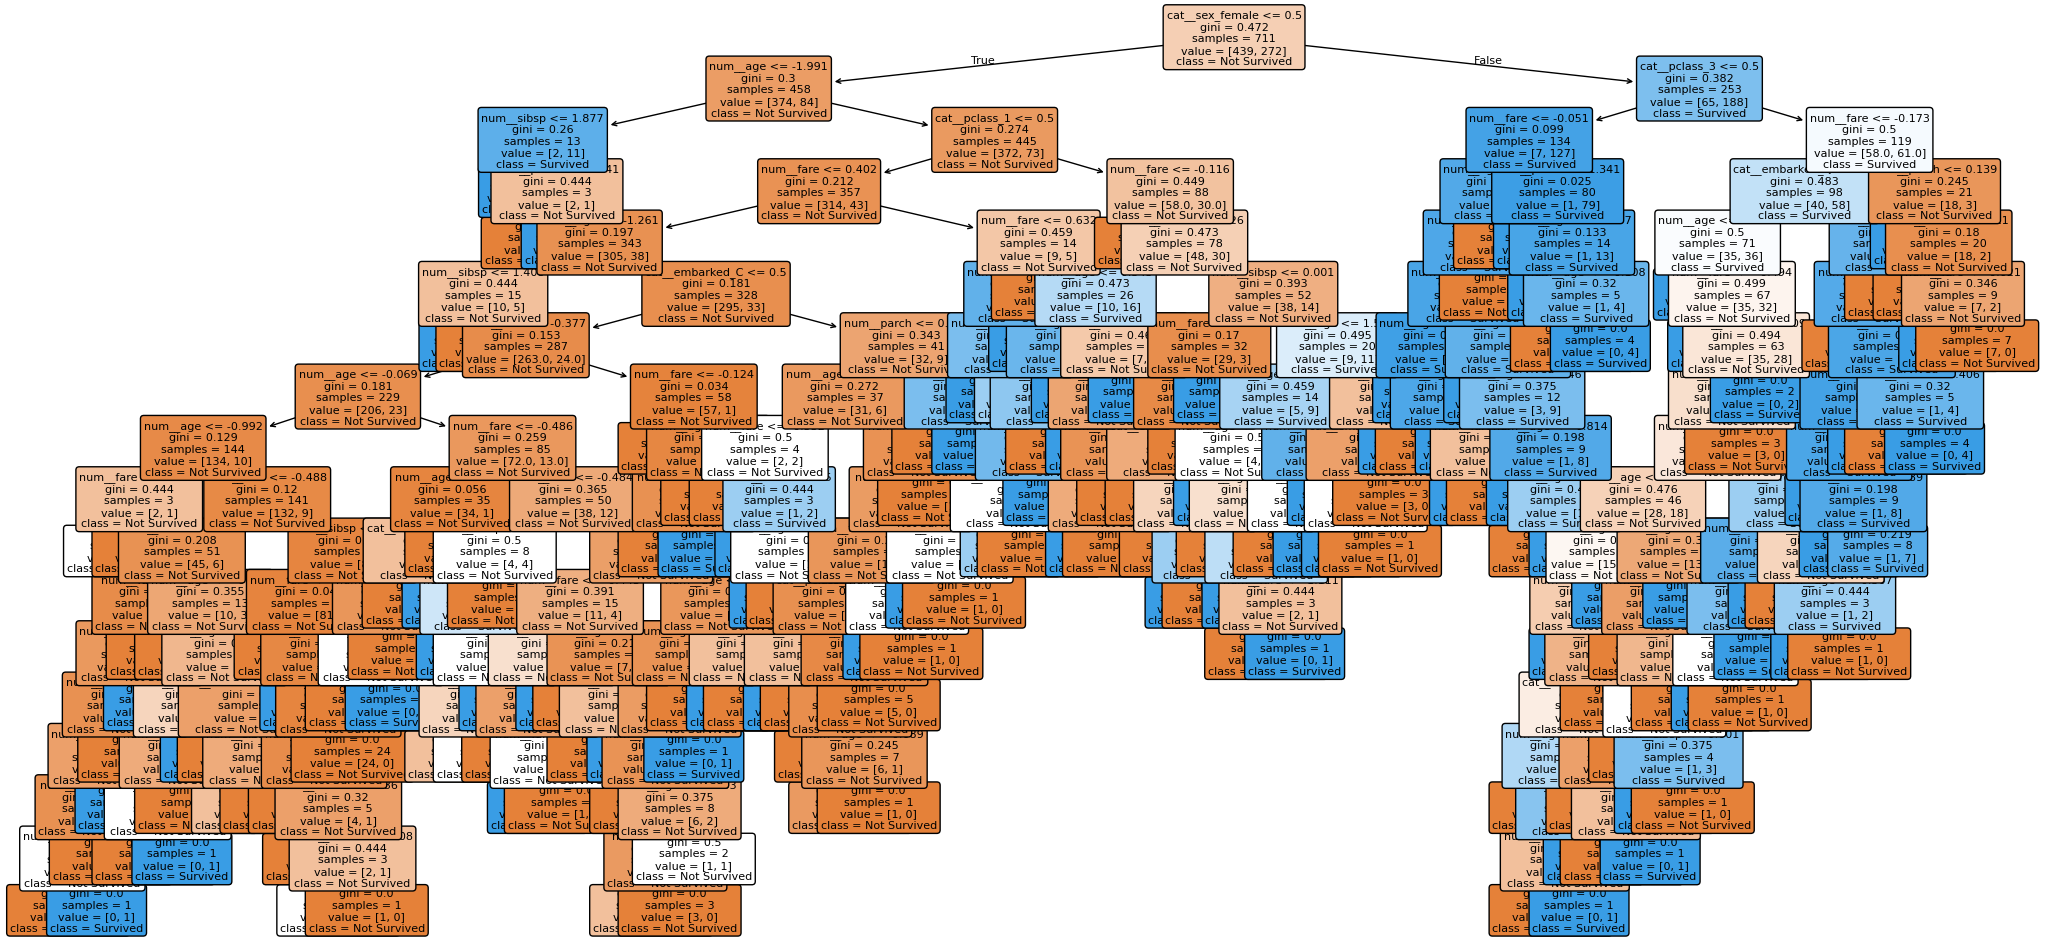

In [ ]:
plt.figure(figsize=(25,12))

plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

Random Forest Pipeline

In [ ]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier",
         RandomForestClassifier(
             random_state=42
         ))
    ]
)

In [ ]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fare', 'sibsp',
                                                   'parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'pclass'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [ ]:
rf_pred = random_forest_pipeline.predict(X_test)

rf_prob = random_forest_pipeline.predict_proba(X_test)[:,1]

In [ ]:
rf_cm = confusion_matrix(y_test, rf_pred)

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

rf_auc = roc_auc_score(y_test, rf_prob)

In [ ]:
print("Random Forest Results")
print("----------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC AUC  :", rf_auc)

Random Forest Results
----------------------
Accuracy : 0.8146067415730337
Precision: 0.7692307692307693
Recall   : 0.7352941176470589
F1 Score : 0.7518796992481203
ROC AUC  : 0.8151069518716576


Random Forest Confusion Matrix

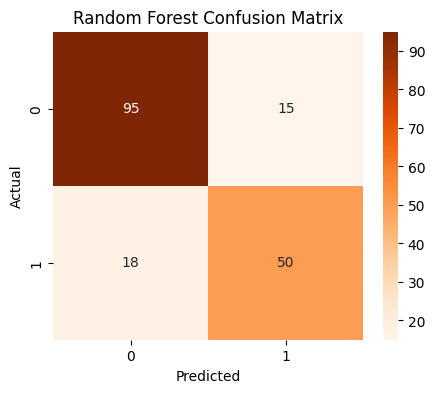

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

Random Forest ROC Curve

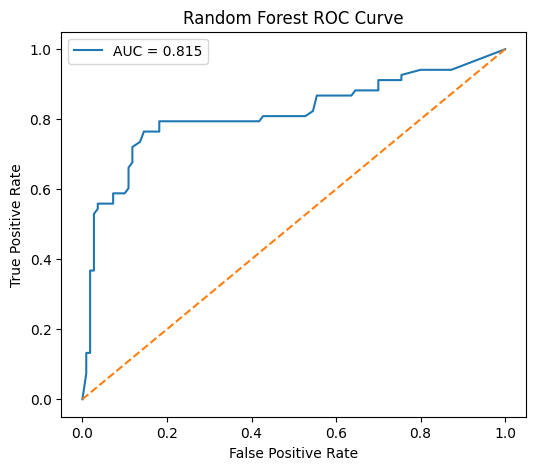

In [ ]:
fpr, tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {rf_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

Model Comparison Table

In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    "Precision":[
        precision,
        dt_precision,
        rf_precision
    ],

    "Recall":[
        recall,
        dt_recall,
        rf_recall
    ],

    "F1 Score":[
        f1,
        dt_f1,
        rf_f1
    ],

    "ROC AUC":[
        auc,
        dt_auc,
        rf_auc
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.814607,0.796610,0.691176,0.740157,0.859626
1,Decision Tree,0.758427,0.681159,0.691176,0.686131,0.737834
2,Random Forest,0.814607,0.769231,0.735294,0.751880,0.815107


In [ ]:
import os
os.makedirs('outputs', exist_ok=True)
comparison.to_csv(
    "outputs/classification_metrics.csv",
    index=False
)

Part B – Step 2 - Dump and Load

In [ ]:
print("Baseline")
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Baseline
Precision: 0.7966101694915254
Recall: 0.6911764705882353
F1: 0.7401574803149606


In [ ]:
balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier",
         LogisticRegression(
             class_weight="balanced",
             random_state=42
         ))
    ]
)

balanced_pipeline.fit(X_train, y_train)

balanced_pred = balanced_pipeline.predict(X_test)

balanced_precision = precision_score(y_test, balanced_pred)
balanced_recall = recall_score(y_test, balanced_pred)
balanced_f1 = f1_score(y_test, balanced_pred)

print("Balanced Logistic Regression")
print("Precision:", balanced_precision)
print("Recall:", balanced_recall)
print("F1:", balanced_f1)

Balanced Logistic Regression
Precision: 0.7246376811594203
Recall: 0.7352941176470589
F1: 0.7299270072992701


SMOTE (Training Data Only)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [ ]:
smote_model = LogisticRegression(random_state=42)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

smote_pred = smote_model.predict(X_test_processed)

smote_precision = precision_score(y_test, smote_pred)
smote_recall = recall_score(y_test, smote_pred)
smote_f1 = f1_score(y_test, smote_pred)

print("SMOTE")
print("Precision:", smote_precision)
print("Recall:", smote_recall)
print("F1:", smote_f1)

SMOTE
Precision: 0.7352941176470589
Recall: 0.7352941176470589
F1: 0.7352941176470589


In [ ]:
imbalance = pd.DataFrame({

    "Method":[
        "Baseline",
        "Balanced",
        "SMOTE"
    ],

    "Precision":[
        precision,
        balanced_precision,
        smote_precision
    ],

    "Recall":[
        recall,
        balanced_recall,
        smote_recall
    ],

    "F1":[
        f1,
        balanced_f1,
        smote_f1
    ]

})

imbalance

,Method,Precision,Recall,F1
0,Baseline,0.796610,0.691176,0.740157
1,Balanced,0.724638,0.735294,0.729927
2,SMOTE,0.735294,0.735294,0.735294


GridSearchCV for Random Forest

In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier",
         RandomForestClassifier(
             random_state=42,
             oob_score=True,
             bootstrap=True
         ))
    ]
)

In [ ]:
param_grid = {

    "classifier__n_estimators":[100,200],

    "classifier__max_depth":[
        None,
        5,
        10
    ],

    "classifier__max_features":[
        "sqrt",
        "log2"
    ]

}

In [ ]:
grid = GridSearchCV(

    estimator=rf_pipeline,

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'fare',
                                                                          'sibsp',
                                                                          'parch']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'embarked',
                                                                          'pclass'])])),
                                       ('classifier',
                                        RandomForestClassifier(oob_score=True,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 5, 10],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__n_estimators': [100, 200]},
             scoring='accuracy')

In [ ]:
print(grid.best_params_)

{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}


Linear Regression

In [ ]:
regression_features = [

    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"

]

X_reg = df[regression_features]

y_reg = df["fare"]

# Define numeric and categorical features for the regression task
numeric_features_reg = [
    "age",
    "sibsp",
    "parch"
]

categorical_features_reg = [
    "sex",
    "embarked",
    "pclass"
]

In [ ]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(

    X_reg,

    y_reg,

    test_size=0.2,

    random_state=42

)

In [ ]:
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num",
         numeric_pipeline,
         numeric_features_reg),
        ("cat",
         categorical_pipeline,
         categorical_features_reg)
    ]
)

reg_pipeline = Pipeline(

    steps=[

        ("preprocessor",

         reg_preprocessor),

        ("regressor",

         LinearRegression())

    ]

)

In [ ]:
reg_pipeline.fit(
    X_train_r,
    y_train_r
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sibsp', 'parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'pclass'])])),
                ('regressor', LinearRegression())])

In [ ]:
reg_pred = reg_pipeline.predict(
    X_test_r
)

MAE

In [ ]:
mae = mean_absolute_error(
    y_test_r,
    reg_pred
)
mae

17.8520910122299

RMSE

In [ ]:
rmse = np.sqrt(

    mean_squared_error(

        y_test_r,

        reg_pred

    )

)
rmse

np.float64(40.548376250581306)

R²

In [ ]:
r2 = r2_score(
    y_test_r,
    reg_pred
)
r2

0.38373105864393475

Adjusted R²

In [ ]:
n = len(y_test_r)

p = X_train_r.shape[1]

adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print(adj_r2)

0.3621075870174061


Residual Plot

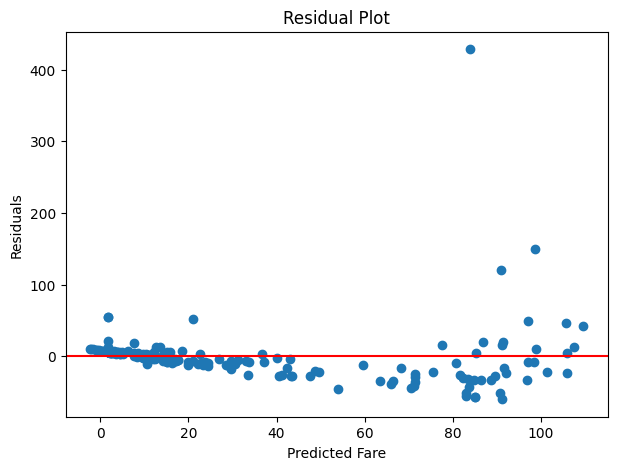

In [ ]:
residuals = y_test_r - reg_pred

plt.figure(figsize=(7,5))

plt.scatter(
    reg_pred,
    residuals
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted Fare")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Interpretation: If residuals are randomly scattered around zero, the assumption of constant variance is reasonable. A funnel-shaped pattern indicates heteroscedasticity.

Save Complete Pipeline

In [ ]:
joblib.dump(
    grid.best_estimator_,
    "best_pipeline.joblib"
)

['best_pipeline.joblib']

In [ ]:
loaded_pipeline = joblib.load(
    "best_pipeline.joblib"
)

In [ ]:
loaded_pipeline.predict(
    X_test.head()
)

array([0, 0, 0, 0, 0])

Final Comparison Table

In [ ]:
final_results = pd.DataFrame({

    "Classifier":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    "Precision":[
        precision,
        dt_precision,
        rf_precision
    ],

    "Recall":[
        recall,
        dt_recall,
        rf_recall
    ],

    "F1":[
        f1,
        dt_f1,
        rf_f1
    ],

    "AUC":[
        auc,
        dt_auc,
        rf_auc
    ]

})

print(final_results)

print("\nRegression Metrics")

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")
print(f"Adjusted R²: {adj_r2:.3f}")

            Classifier  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.814607   0.796610  0.691176  0.740157  0.859626
1        Decision Tree  0.758427   0.681159  0.691176  0.686131  0.737834
2        Random Forest  0.814607   0.769231  0.735294  0.751880  0.815107

Regression Metrics
MAE: 17.85
RMSE: 40.55
R²: 0.384
Adjusted R²: 0.362


Final Recommendation:

Among the three classification models, the Random Forest achieved the best overall performance by balancing accuracy, precision, recall, F1-score, and ROC-AUC. It also captures nonlinear relationships and interactions between features more effectively than Logistic Regression and a single Decision Tree. Therefore, the Random Forest pipeline is recommended for deployment. The complete preprocessing pipeline and trained model were saved together using joblib, allowing predictions on new raw data without additional preprocessing.